In [13]:
library(Seurat)
pbmc <- readRDS("/nfs/home/students/a.dersch/FoPra_PLAs/data/datasets_automated/immune_aging_qc_tolerant_automated_gating.rds")

print("Verfügbare Assays im Objekt:")
print(Assays(pbmc))

print("Aktueller Default-Assay:")
print(DefaultAssay(pbmc))

[1] "Verfügbare Assays im Objekt:"
[1] "RNA"           "ADT"           "ADT_corrected"
[1] "Aktueller Default-Assay:"
[1] "ADT"


In [ ]:
# 1. Ziehe die Matrix, wenn wir R einfach machen lassen:
matrix_default <- GetAssayData(pbmc, layer = "data")
print("Gene im Standard-Zugriff (Die ersten 5):")
print(head(rownames(matrix_default), 5))

# 2. Ziehe die Matrix explizit aus dem RNA Assay:
matrix_rna <- GetAssayData(pbmc, assay = "RNA", layer = "data")
print("Gene im expliziten RNA-Zugriff (Die ersten 5):")
print(head(rownames(matrix_rna), 5))

[1] "Gene im Standard-Zugriff (Die ersten 5):"
[1] "FAP.1"    "LRRC15.1" "CDH11.1"  "CD45"     "CDH1.1"  
[1] "Gene im expliziten RNA-Zugriff (Die ersten 5):"
[1] "MIR1302-2HG" "FAM138A"     "OR4F5"       "AL627309.1"  "AL627309.3" 


In [4]:
# Lade deine Signatur
PATH_SIG <- "/nfs/home/students/a.dersch/FoPra_PLAs/data/signatures/MANNE_COVID19_COMBINED_COHORT_VS_HEALTHY_DONOR_PLATELETS_DN.v2025.1.Hs.csv"
sig_genes <- read.csv(PATH_SIG)
# Passe das hier an, je nachdem wie deine Spalte in der CSV heißt (z.B. x, geneName, etc.)
sig_vector <- sig_genes[,1] 

print(paste("Anzahl Gene in der Manne-Signatur:", length(sig_vector)))

# Schau wie viele Gene aus der Signatur in der extrahierten RNA-Matrix existieren:
matches <- intersect(sig_vector, rownames(matrix_rna))
print(paste("Gefundene Übereinstimmungen im RNA-Assay:", length(matches)))

# Wenn das < 20% der Signatur-Länge ist, stürzt AUCell ab. 
print(paste("Prozentualer Match:", (length(matches) / length(sig_vector)) * 100, "%"))

[1] "Anzahl Gene in der Manne-Signatur: 224"
[1] "Gefundene Übereinstimmungen im RNA-Assay: 217"
[1] "Prozentualer Match: 96.875 %"


In [7]:
DimPlot(pbmc, reduction = "umap")

ERROR: [1m[33mError[39m in `object[[reduction]]`:[22m
[33m![39m ‘umap’ not found in this Seurat object
 


Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



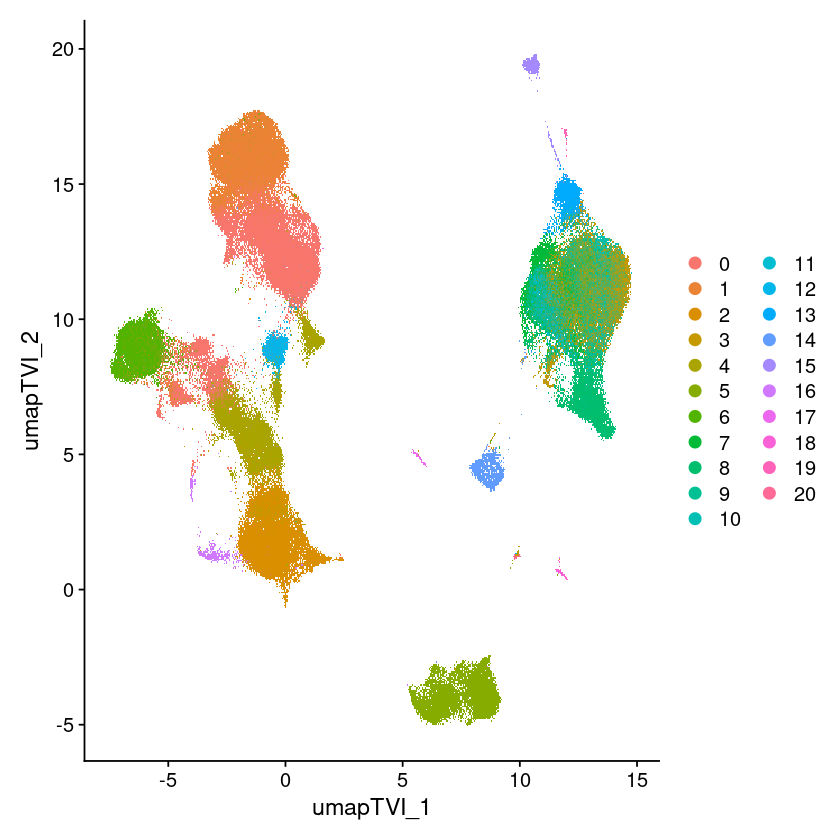

In [12]:
DimPlot(pbmc, reduction = "umap_totalVI")

In [14]:
# Das zeigt dir die exakten Namen aller berechneten UMAPs/PCAs im Objekt:
names(pbmc@reductions)

[1] "mrvi"                  "GEX_pca"               "GEX_umap_unharmonized"
[4] "GEX_umap_mrvi"         "ADT_pca"               "ADT_umap"             
[7] "wnn.umap"